In [1]:
from pathlib import Path
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import os 
from nilearn import datasets, plotting
from nilearn.image import smooth_img

## Loading epoched data and calculating group-level responses

The preprocessed and epoched MEG data are loaded from the `epoched_data`
directory. Each participant has a corresponding FIF file containing
epochs time-locked to the four experimental event types.

The four event conditions are:

| Trigger | Condition |
|---------|-----------|
| 9       | Stay Left |
| 13      | Stay Right |
| 17      | Shift Left |
| 21      | Shift Right |

For each participant and condition, the neural response is averaged
across trials. This produces one subject-level response for each
condition, with dimensions:

`nodes × time points`

The subject-level responses are then averaged across participants to
obtain a group-level response for each condition.

This two-step averaging procedure ensures that each participant
contributes one response per condition to the group average, rather
than participants with more trials contributing disproportionately.

### Time-window analysis

After calculating the group-level responses, we select a specific
post-event time window for further analysis.

Here, the analysis focuses on the interval from **0 to 100 ms after
event onset**.

For each condition, the signal is averaged across this time window,
resulting in one value per MEG node.

The resulting data therefore have the dimensions:

`conditions × nodes`

These node-level weights can subsequently be used for visualization,
comparison between conditions, or as spatial patterns for downstream
analyses.

In [ ]:
data_path = Path("/path/to/your/data") 

files = sorted(data_path.glob("Sub*_epo.fif"))
all_epochs = [mne.read_epochs(f, preload=True) for f in files]

conditions = ["9", "13", "17", "21"]


titles = {
    "9": "Stay Left",
    "13": "Stay Right",
    "17": "Shift Left",
    "21": "Shift Right"
}
#%%
group_data = {cond: [] for cond in conditions} #list  subject-level averages per condition

for epochs in all_epochs:

    for cond in conditions:

        if cond in epochs.event_id: #chek if exists 

            data = epochs[cond].get_data().mean(axis=0) #averge data returs 99 sources by 770 tineppints , avragesover trials (print epochs to check)
            group_data[cond].append(data)
            #print(cond, len(group_data[cond])) check length should be subject

group_avg = {
    cond: np.mean(group_data[cond], axis=0)
    for cond in conditions
}

for cond in conditions:
    print(cond, titles[cond], group_avg[cond].shape)
#%%
#selecting a sepcific time window to plot the images the epiochs have lngth -0.5 to 1s

times = all_epochs[0].times
tmin = 0
tmax = 0.1

time_mask = (times >= tmin) & (times <= tmax)

group_weights = {}

for cond in conditions:

    weights = group_avg[cond][:, time_mask].mean(axis=1)

    group_weights[cond] = weights
    
   
group_weights[cond].shape

Reading /home/uranus/Scrivania/MEG_replay/epoched_data/Sub10_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -499.51 ...    1000.98 ms
        0 CTF compensation matrices available
Not setting metadata
360 matching events found
No baseline correction applied
0 projection items activated
Reading /home/uranus/Scrivania/MEG_replay/epoched_data/Sub11_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -499.51 ...    1000.98 ms
        0 CTF compensation matrices available
Not setting metadata
354 matching events found
No baseline correction applied
0 projection items activated
Reading /home/uranus/Scrivania/MEG_replay/epoched_data/Sub12_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -499.51 ...    1000.98 ms
        0 CTF compensation matrices available
Not setting metadata
361 matching events found
No baseline correction applied
0 projection items activated
Reading /home/uranus/Scrivania/MEG_replay/epoched

(99,)

##  Visualizing the group-average response over time

The previous analysis reduced each condition to a single value per node
by averaging within a selected time window.

Here, we retain the complete epoch time course to visualize how the
group-level response evolves over time.

For each condition, trials are first averaged within each participant.
The resulting subject-level responses are then averaged across
participants.

The resulting matrix has dimensions:

`MEG nodes × time points`

This matrix is visualized as a heatmap, with:

- **x-axis:** time relative to event onset;
- **y-axis:** MEG node;
- **color:** mean signal amplitude.

A separate heatmap is generated for each experimental condition.
The vertical axis represents the 99 MEG nodes, while the horizontal
axis spans the complete epoch from −0.5 to +1.0 seconds.

The same color scale is used across conditions so that the magnitude
and temporal evolution of the responses can be compared directly.

9 (Stay Left): (99, 770)
13 (Stay Right): (99, 770)
17 (Shift Left): (99, 770)
21 (Shift Right): (99, 770)


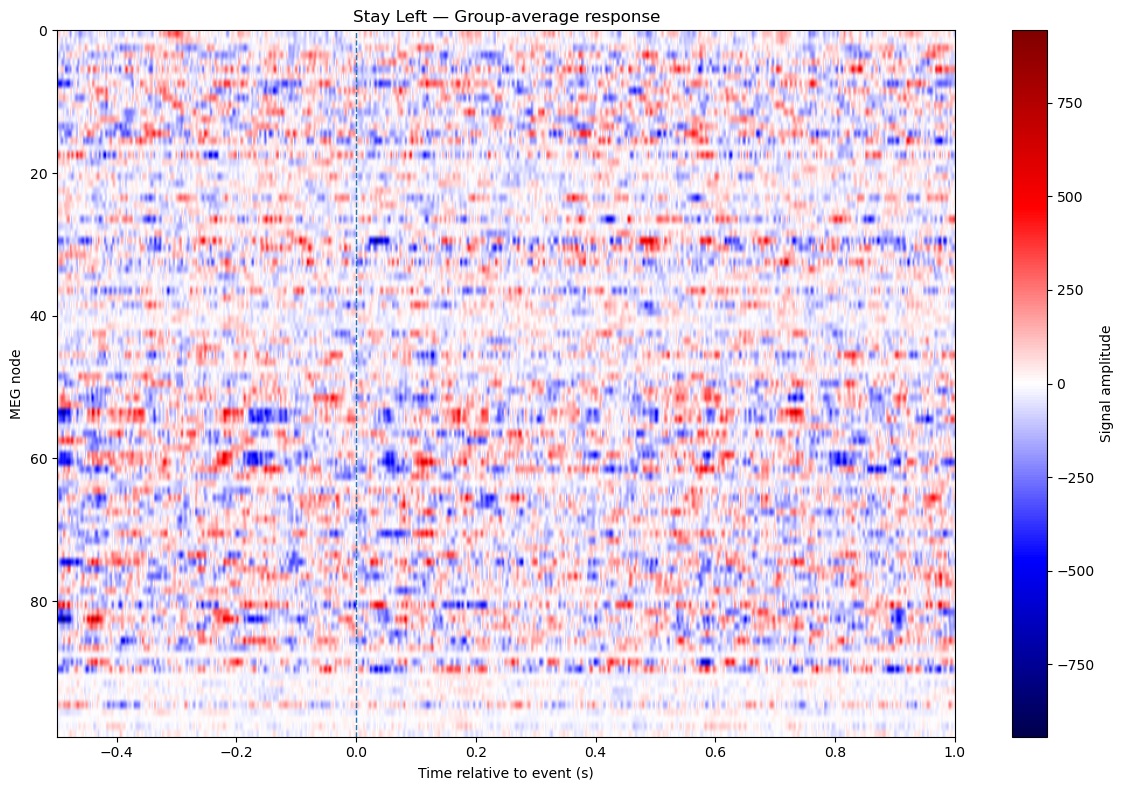

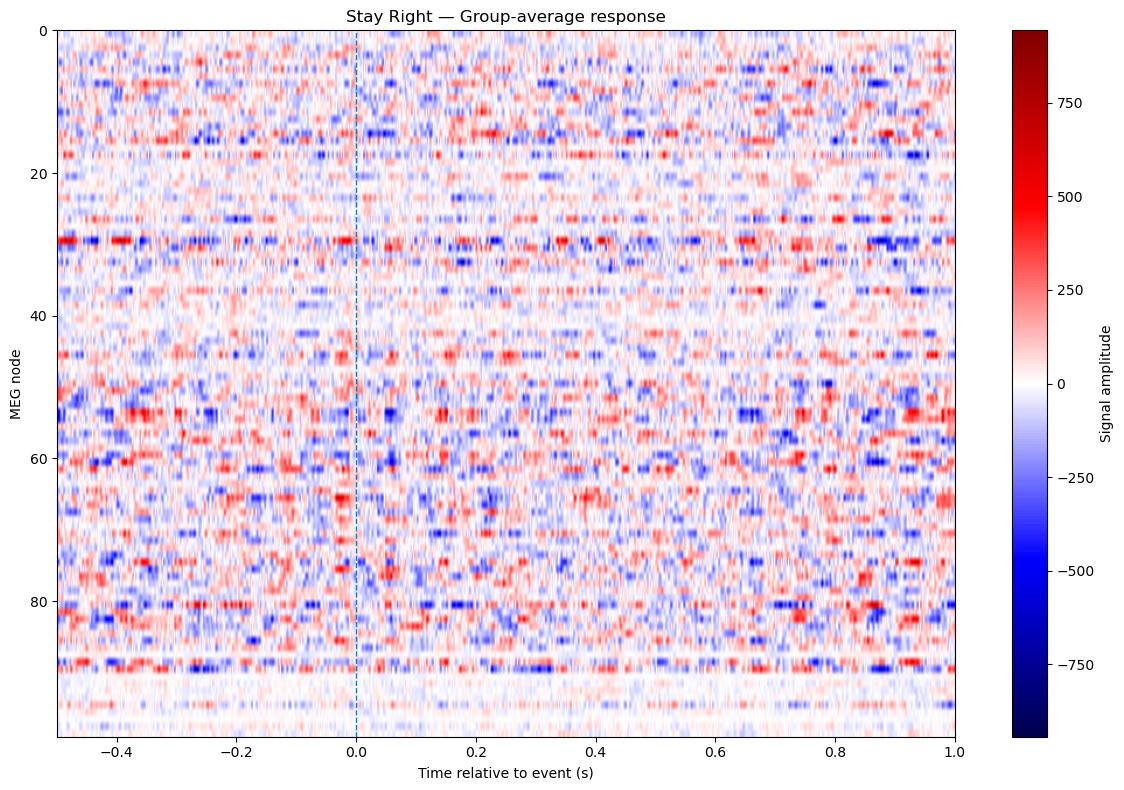

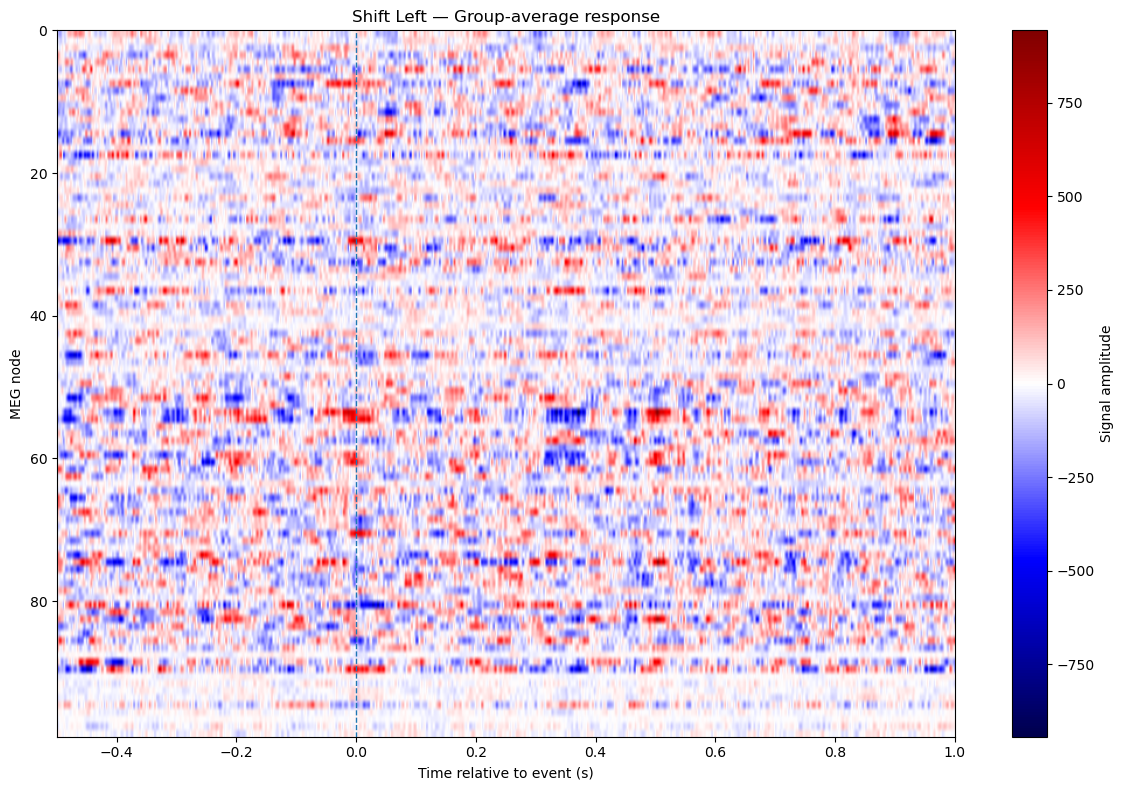

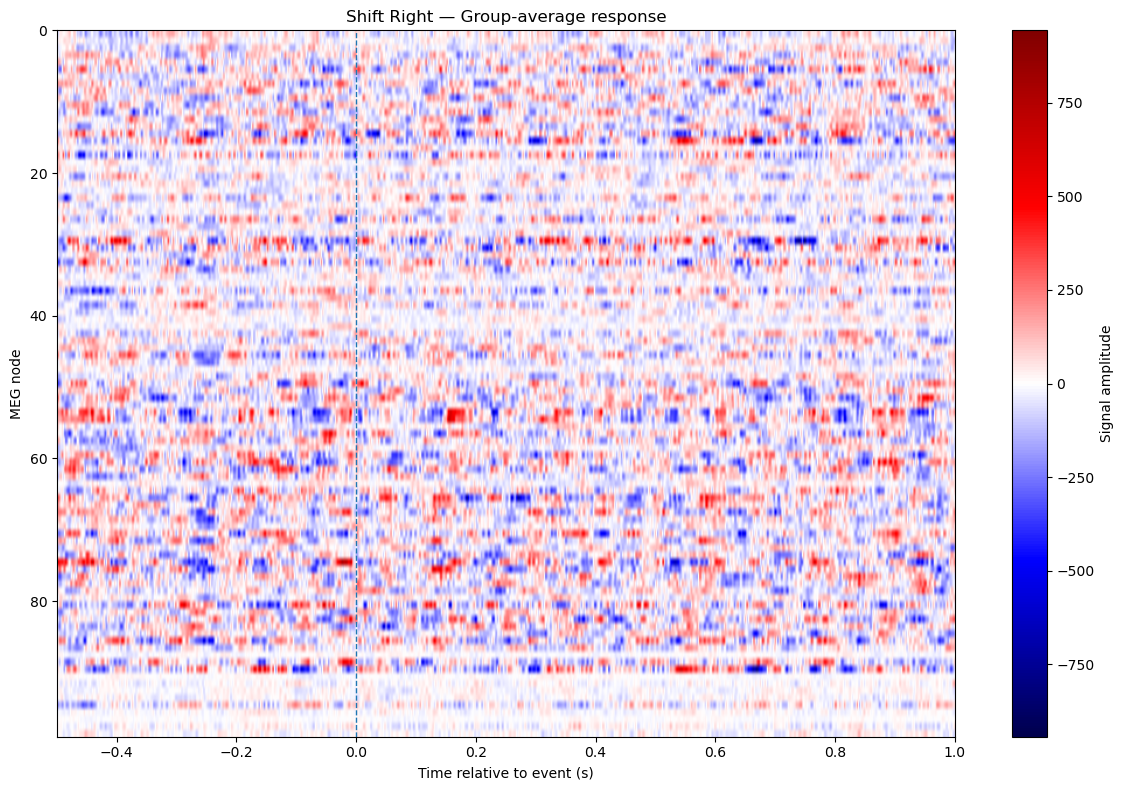

In [4]:
# =========================================================
# GROUP-AVERAGE TIME-RESOLVED RESPONSE
# =========================================================

group_time_data = {}

for cond in conditions:

    subject_data = []

    for epochs in all_epochs:

        if cond in epochs.event_id:

            # Average trials within participant
            data = epochs[cond].get_data().mean(axis=0)

            # data = nodes × time
            subject_data.append(data)

    # Average participants
    group_time_data[cond] = np.mean(
        subject_data,
        axis=0
    )

    print(
        f"{cond} ({titles[cond]}): "
        f"{group_time_data[cond].shape}"
    )

# =========================================================
# HEATMAP: NODES × TIME
# =========================================================

times = all_epochs[0].times

# Common color scale across all conditions
all_values = np.concatenate(
    [group_time_data[cond].ravel() for cond in conditions]
)

vmax = np.max(np.abs(all_values))
vmin = -vmax

for cond in conditions:

    data = group_time_data[cond]

    fig, ax = plt.subplots(
        figsize=(12, 8)
    )

    im = ax.imshow(
        data,
        aspect="auto",
        origin="upper",
        extent=[
            times[0],
            times[-1],
            data.shape[0],
            0
        ],
        cmap="seismic",
        vmin=vmin,
        vmax=vmax
    )

    # Event onset
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel(
        "Time relative to event (s)"
    )

    ax.set_ylabel(
        "MEG node"
    )

    ax.set_title(
        f"{titles[cond]} — Group-average response"
    )

    cbar = plt.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(
        "Signal amplitude"
    )

    plt.tight_layout()
    plt.show()

##  Visualizing condition-specific activity on the glass brain

At this stage, the signal has been averaged across the selected
time window (0–100 ms), so each condition is represented by a single
value for each MEG node.

The resulting `group_weights` therefore contain:

`1 condition × 99 nodes`

To visualize the spatial distribution of these responses, the
coordinates of the 99 MEG nodes are loaded from the anatomical
coordinate file.

Each node is then represented as a marker at its corresponding
three-dimensional brain coordinate.

### Color mapping

The node values are mapped onto a diverging red–blue color scale.

The color range is defined symmetrically around zero using the maximum
absolute value across **all conditions**. This ensures that the same
color scale is used for every condition and therefore allows direct
visual comparison between conditions.

- Positive values are represented toward one end of the color scale.
- Negative values are represented toward the opposite end.
- Values close to zero are represented near the center of the scale.

The same node size and spatial coordinates are used across conditions.

A glass-brain visualization is first generated showing the locations
of all 99 nodes. Subsequently, one glass-brain plot is generated for
each experimental condition.

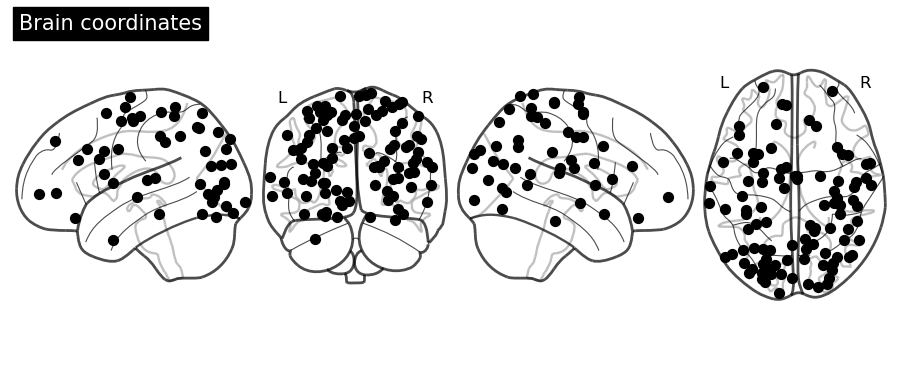

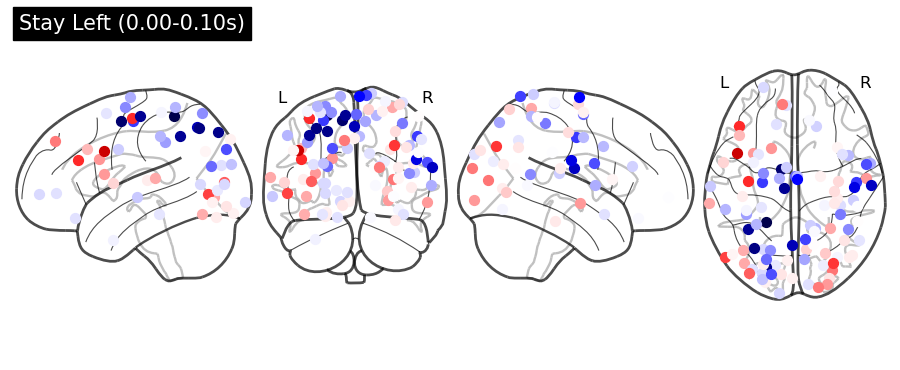

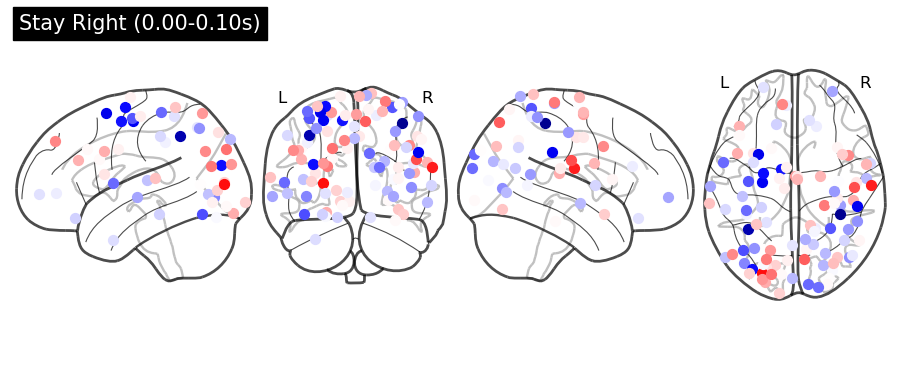

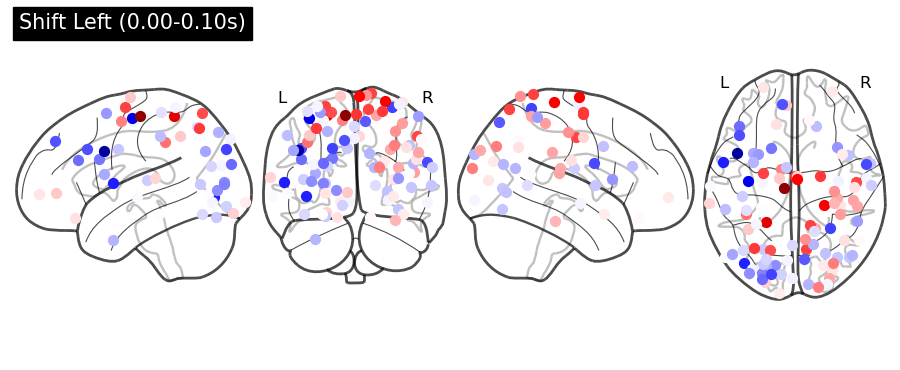

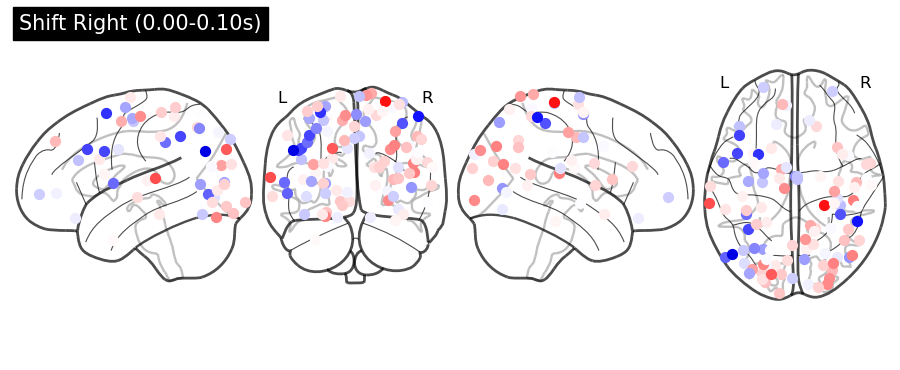

In [ ]:
#here you have avergae signal of the seelcting itme mask so only one dimension in time 
    #ow plit this 
 #%%
####----GLASS BRAIN 
#fidning the cooridnates on the brain 
coordinates = pd.read_excel(
    Path("/path/to/your/data/config_net_labels_after_VIVI_DEF_MAU_last.xlsx")
)

coords = coordinates[["x", "y", "z"]].values
display = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    colorbar=False,
    title="Brain coordinates"
)

display.add_markers(
    coords,
    marker_color="black",
    marker_size=50
)

plt.show()


all_vals = np.concatenate(list(group_weights.values()))
vmax = np.max(np.abs(all_vals))
vmin = -vmax

norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.seismic

for cond in conditions:

     display = plotting.plot_glass_brain(
         None,
         display_mode="lyrz",
         colorbar=False,
         title=f"{titles[cond]} ({tmin:.2f}-{tmax:.2f}s)"
     )

     colors = cmap(norm(group_weights[cond])) #normalising values per codnitions adn tranforming them to colours 

     for coord, color in zip(coords, colors): #zip pair elements from multiple sequences together
         display.add_markers(
             [coord],
             marker_color=[color],
            marker_size=50
         )

     plt.show()
    

## Creating volumetric MNI-space maps

The node-level condition weights are converted into volumetric NIfTI
images in MNI space to enable a more continuous visualization of the
spatial distribution of the MEG responses.

### MNI template

An MNI152 template with 2 mm spatial resolution is used as the
reference anatomical space. The template provides both the voxel
dimensions and the affine transformation required to convert between
MNI coordinates (millimetres) and voxel indices.

### Mapping node values to voxels

For each experimental condition, the 99 node coordinates are converted
from MNI coordinates (mm) to voxel coordinates using the inverse affine
transformation of the MNI template.

Each node's condition-specific weight is then assigned to the
corresponding voxel in the template volume.

If multiple nodes fall within the same voxel, their values are summed.

### Spatial smoothing

The resulting sparse volume is spatially smoothed using a Gaussian
kernel with a **10 mm FWHM**.

Smoothing produces a more spatially continuous representation of the
node-level activity and allows visualization of spatial patterns rather
than isolated individual voxels.

### Normalization

After smoothing, each condition-specific map is normalized by its
maximum absolute value. The resulting values are scaled to a maximum
absolute value of 5.

This normalization is applied independently to each condition.

### Visualization

The resulting NIfTI maps are displayed on the MNI152 anatomical
template using axial (`z`) slices.

The z-axis is divided into three groups of slices so that the full
range of selected anatomical coordinates can be visualized for each
condition.

A threshold of 0.5 is applied during visualization to suppress very
small values.

/tmp/ipykernel_1472661/534290128.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


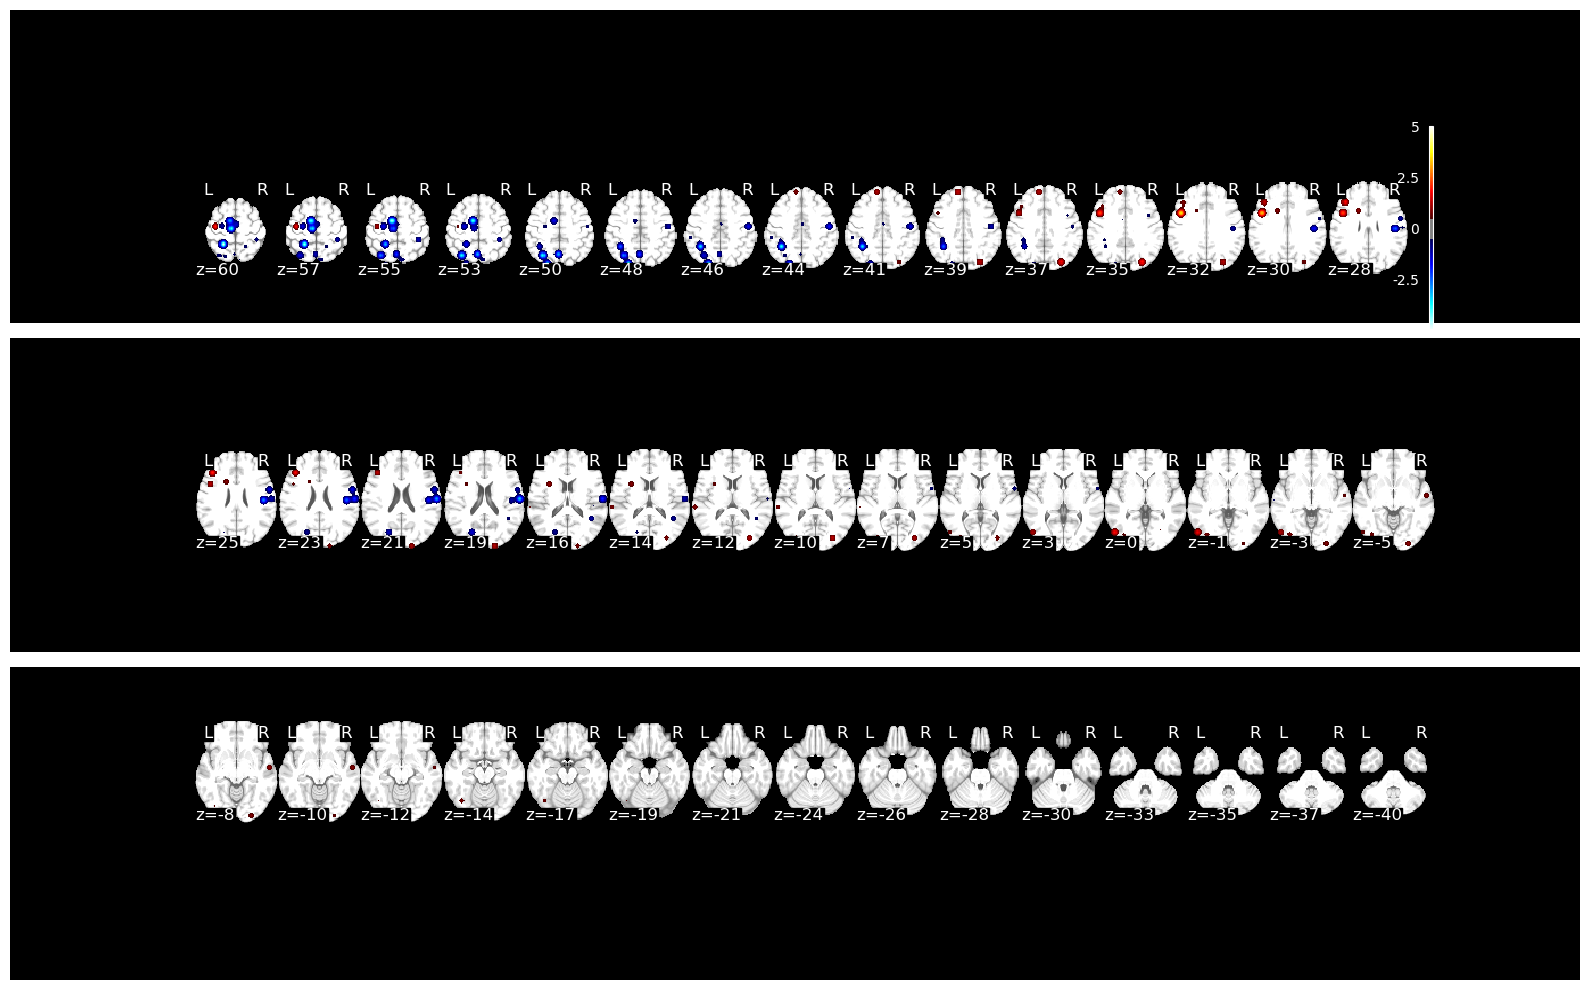

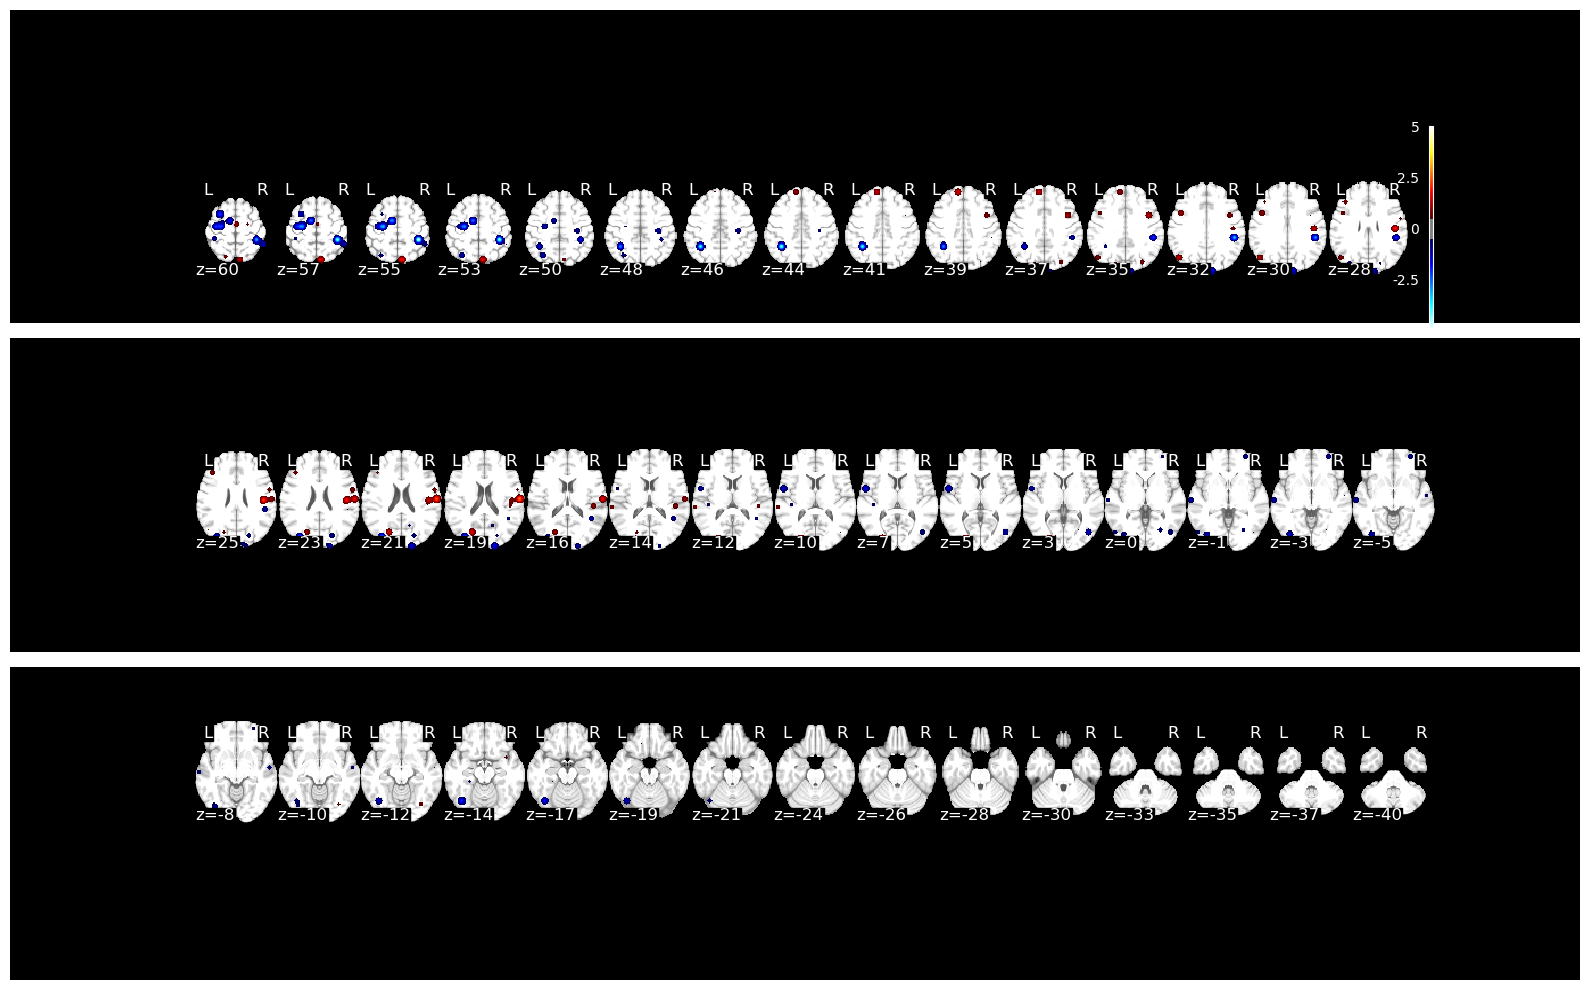

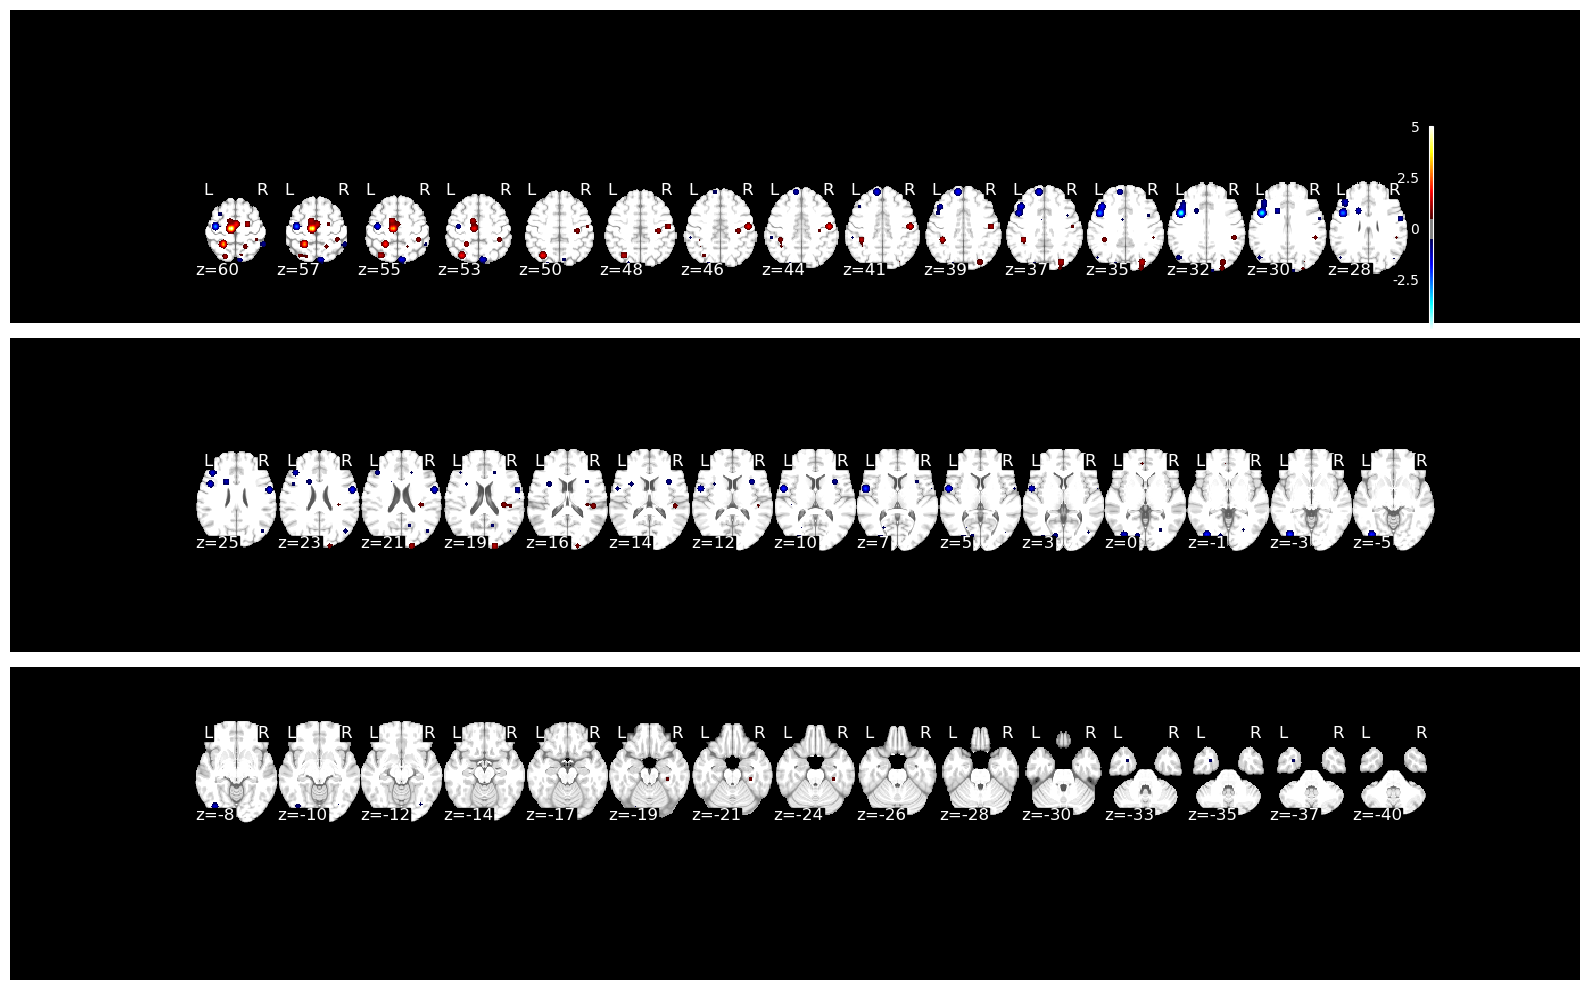

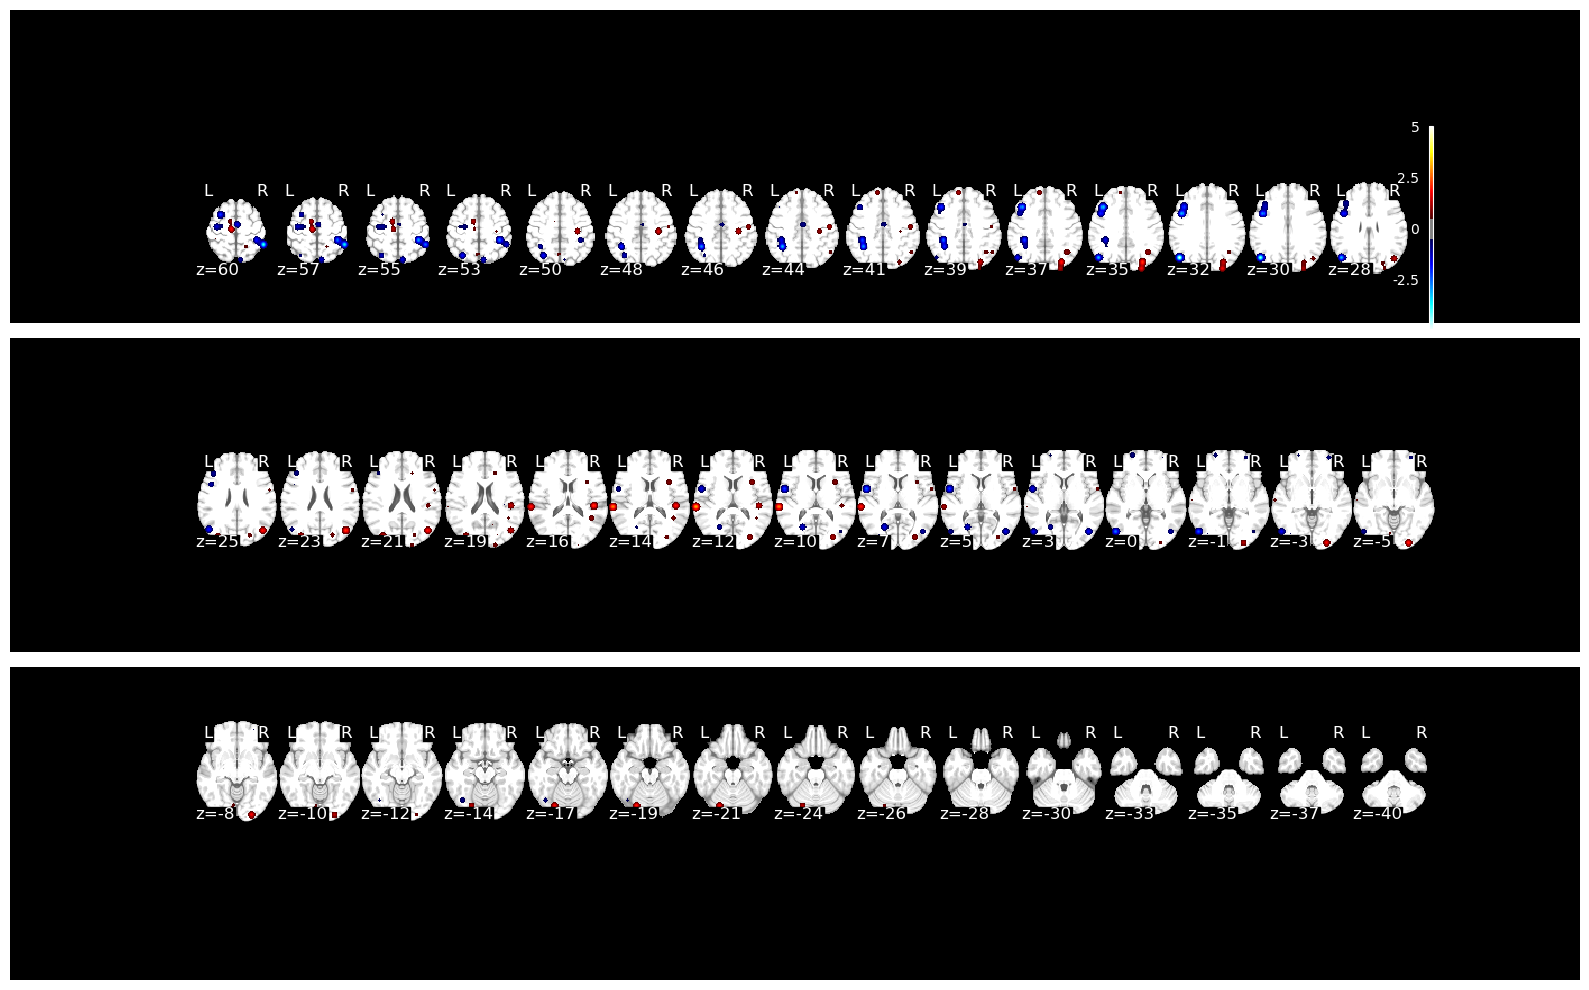

In [5]:


# ------------------------------------------------------------------
# Load MNI template (change resolution=1 or resolution=2)
# ------------------------------------------------------------------

mni_template = datasets.load_mni152_template(resolution=2)

shape = mni_template.shape
affine = mni_template.affine

# ------------------------------------------------------------------
# Convert MNI coordinates (mm) -> voxel indices
# ------------------------------------------------------------------

def coord_to_voxel(coord):

    voxel = np.round(
        np.linalg.inv(affine) @ np.append(coord, 1)
    )[:3].astype(int)

    return voxel


# ------------------------------------------------------------------
#  NIfTI images
# ------------------------------------------------------------------

nifti_images = {}

for cond in conditions:

    weights = group_weights[cond]

    volume = np.zeros(shape, dtype=float)

    # 
    for coord, value in zip(coords, weights):

        x, y, z = coord_to_voxel(coord)

        if (
            0 <= x < shape[0]
            and 0 <= y < shape[1]
            and 0 <= z < shape[2]
        ):
            volume[x, y, z] += value

    # Convert to NIfTI
    img = nib.Nifti1Image(volume, affine)

    # --------------------------------------------------------------
    # Smooth 
    # --------------------------------------------------------------

    img = smooth_img(img, fwhm=10)

    #  normalization
    data = img.get_fdata()

    vmax = np.max(np.abs(data))

    if vmax > 0:
        data = data / vmax * 5

    nifti_images[cond] = nib.Nifti1Image(data, affine)


# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

# ------------------------------------------------------------------
# Z coords
# ------------------------------------------------------------------

z_coords = np.linspace(-40, 60, 45)
z_coords = sorted(z_coords, reverse=True)

# ------------------------------------------------------------------
# BASE DIRECTORY (define ONCE)
# ------------------------------------------------------------------

#base_dir = Path("/home/uranus/MEG_replay/maps")
#base_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# LOOP
# ------------------------------------------------------------------

for cond in conditions:

    fig = plt.figure(figsize=(16, 10))

    cond_name = titles[cond]

    # IMPORTANT: keep it as Path, do NOT convert to string
    #save_dir = base_dir / cond_name
    #save_dir.mkdir(parents=True, exist_ok=True)

    for i in range(3):

        ax = plt.subplot(3, 1, i + 1)

        plotting.plot_stat_map(
            nifti_images[cond],
            bg_img=mni_template,
            display_mode="z",
            cut_coords=z_coords[i*15:(i+1)*15],
            cmap="cold_hot",
            threshold=0.5,   
            dim=-0.5,
            colorbar=(i == 0),
            annotate=True,
            axes=ax,
        )

    plt.tight_layout()

    #save_path = save_dir / f"{cond_name}_zmaps1000ms.png"

   # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
